# Volatility-managed factors

Factor investing usually begins by asking which return sources to hold. Volatility management asks a different question: **should exposure to the same factor vary over time?** Moreira and Muir (2017) propose reducing factor exposure after high realized variance and increasing it after calm months. This notebook develops that argument first and then applies the rule to the Fama–French factors and momentum.

The emphasis is deliberately narrow. We use a transparent, one-month-lagged realized-variance rule, evaluate whether the managed returns span their unmanaged counterparts, and then examine volatility-managed momentum in more detail. The prepared data and empirical conventions follow the companion [volatility-management project](https://github.com/jacobkorsgaard/volatility-managed-factors-and-momentum); reusable calculations are called from this library.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from factor_asset_pricing.asset_pricing_tests import factor_regressions, sharpe_ratio, spanning_regression
from factor_asset_pricing.volatility_management import volatility_managed_return

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.3f}".format

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
VM_PROJECT = PROJECT_ROOT.parent / "01_complete" / "volatility-management-and-liquidity"
DEFAULT_DATA_PATH = VM_PROJECT / "data" / "processed" / "managed_factors.parquet"
DATA_PATH = Path(os.environ.get("FAP_VOLATILITY_DATA", DEFAULT_DATA_PATH))

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Prepared volatility-managed factor data were not found. "
        "Set FAP_VOLATILITY_DATA to the prepared Parquet file."
    )

data = pd.read_parquet(DATA_PATH)
data["date"] = pd.to_datetime(data["date"])
data = data.set_index("date").sort_index()

print(f"Prepared sample: {data.index.min():%B %Y}–{data.index.max():%B %Y}")

Prepared sample: July 1926–July 2026


## 1. The economic intuition behind volatility management

The economic intuition in Moreira and Muir (2017) rests on a simple asymmetry. **Volatility clustering**—the tendency for high-volatility periods to be followed by high-volatility periods, and calm periods by calm periods—is one of the most established empirical regularities in financial returns. This persistence makes recent realized volatility informative about near-term risk: a factor that was volatile this month is likely to remain relatively volatile next month. If its conditional expected return does not rise proportionally with conditional variance, then taking the same exposure in calm and turbulent states is inefficient. Scaling exposure down following high variance, and up following low variance, can therefore improve the factor's reward per unit of risk.

This is a conditional Sharpe-ratio argument rather than a new return predictor. The rule uses yesterday's observable risk to choose today's exposure. Moreira and Muir show that the central result is robust to volatility estimates beyond the simplest one-month lagged measure and across several factor portfolios. The simple lagged-realized-variance rule nevertheless works well and remains the most transparent baseline, which is why we use it here. Its success still requires volatility to be forecastable and expected returns not to offset that variation one-for-one; it is not guaranteed to improve every factor.

### 1.1 Construction and information timing

For factor $f$, monthly realized variance is estimated from its daily returns:

$$
RV_t=\sum_{d\in t}\left(f_d-\bar f_t\right)^2.
$$

The return earned in month $t$ is scaled only by variance observed in month $t-1$:

$$
f_t^{VM}=w_t f_t, \qquad w_t=\frac{c}{RV_{t-1}}.
$$

The positive constant $c$ puts the managed and unmanaged strategies on a comparable volatility scale. Because a constant rescaling changes mean and volatility proportionally, it does not change the Sharpe ratio or the $t$-statistic of an intercept. Here $c$ is estimated over the comparison sample, following the replication convention; it is therefore an ex-post normalization device, not a real-time volatility target.

The strategy is attractive when the resulting mean-to-volatility ratio,

$$
SR(f^{VM})=\frac{E[f_t^{VM}]}{\sigma(f_t^{VM})},
$$

exceeds that of the unmanaged factor. The inverse-variance rule can create substantial leverage in calm periods. The results below are gross of financing costs, transaction costs, and leverage constraints, so they should be interpreted as evidence about the timing mechanism rather than as a directly investable backtest.

## 2. Example: Volatility-managing the Fama–French factors and momentum

We apply the same rule to the market excess return, SMB, HML, RMW, CMA, and momentum. The companion project constructs monthly realized variance from daily factor returns and stores both the lagged variance and the resulting managed return. Before studying performance, we verify that these prepared series agree with the library's generic scaling function.

### 2.1 Volatility clustering

We begin with the monthly factor-return histories. If volatility were constant, large and small return fluctuations would be distributed relatively evenly through time. Instead, turbulent observations visibly occur in clusters, providing the empirical motivation for using recent realized volatility to adjust next month's exposure.

Construction check passed: all six prepared strategies match the library rule.


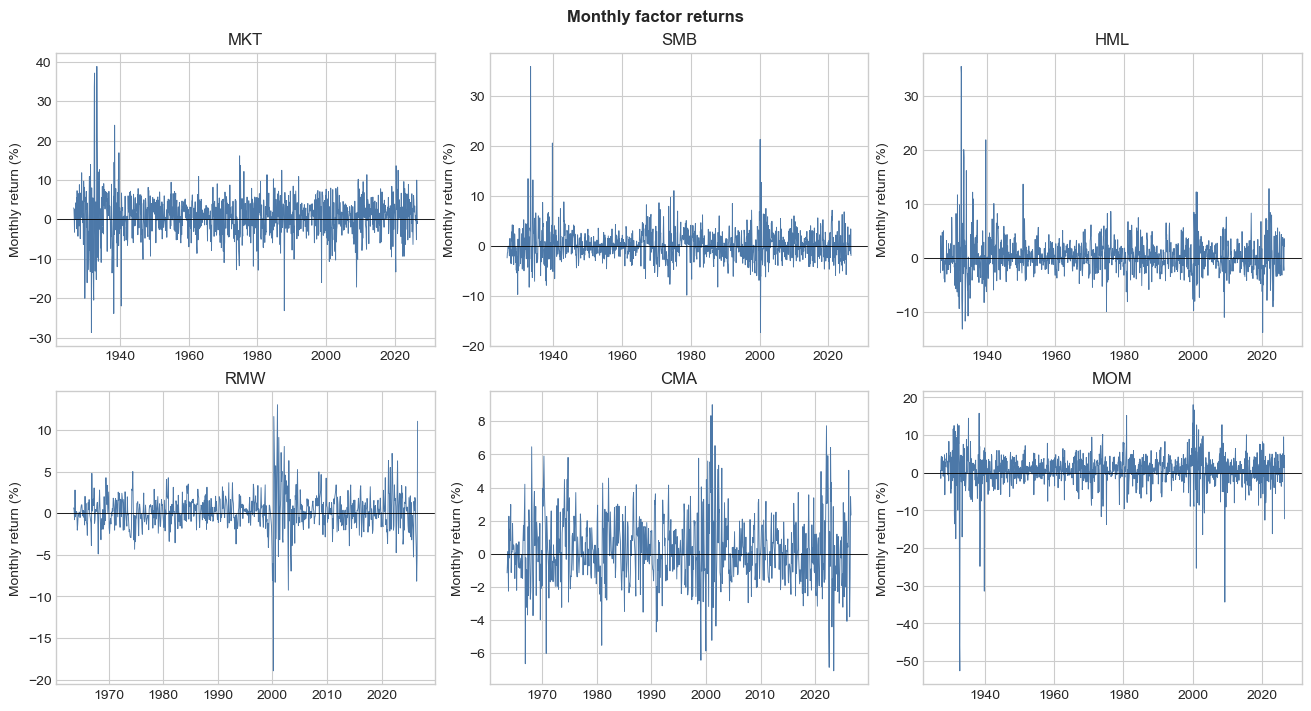

In [2]:
factor_columns = {
    "MKT": ("mkt_rf", "rv_mkt_rf_lag1", "managed_mkt_rf", "weight_mkt_rf"),
    "SMB": ("smb", "rv_smb_lag1", "managed_smb", "weight_smb"),
    "HML": ("hml", "rv_hml_lag1", "managed_hml", "weight_hml"),
    "RMW": ("rmw", "rv_rmw_lag1", "managed_rmw", "weight_rmw"),
    "CMA": ("cma", "rv_cma_lag1", "managed_cma", "weight_cma"),
    "MOM": ("mom", "rv_mom_lag1", "managed_mom", "weight_mom"),
}

integrity_rows = []
for name, (return_col, lagged_rv_col, managed_col, weight_col) in factor_columns.items():
    # The stored measure is already lagged, so lag=1 is reproduced by shifting it back once here.
    current_rv = data[lagged_rv_col].shift(-1)
    rebuilt = volatility_managed_return(
        data[return_col], current_rv, scaling="inverse_variance", lag=1, normalize=False
    )["managed_return"]
    valid = pd.concat([rebuilt, data[managed_col]], axis=1).dropna()
    ratio = valid.iloc[:, 1] / valid.iloc[:, 0]
    integrity_rows.append({
        "Factor": name,
        "Minimum weight": data[weight_col].min(),
        "Correlation with library reconstruction": valid.corr().iloc[0, 1],
        "Variation in implied scale constant": ratio.std(),
    })

integrity = pd.DataFrame(integrity_rows).set_index("Factor")
assert integrity["Correlation with library reconstruction"].min() > 0.999999
assert integrity["Variation in implied scale constant"].max() < 1e-10
print("Construction check passed: all six prepared strategies match the library rule.")

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=False, constrained_layout=True)
for ax, (name, (return_col, _, _, _)) in zip(axes.flat, factor_columns.items()):
    series = 100 * data[return_col].dropna()
    ax.plot(series.index, series, color="#4C78A8", linewidth=0.65)
    ax.axhline(0, color="black", linewidth=0.6)
    ax.set(title=name, xlabel="", ylabel="Monthly return (%)")
fig.suptitle("Monthly factor returns", weight="bold")
plt.show()

The return histories display a familiar feature of financial data: large observations tend to arrive in clusters rather than being distributed evenly through time. The clustering is especially visible around major periods of market stress and is present in both the market and characteristic factors. This persistence is the empirical information exploited by the lagged-volatility rule; the strategy does not need to forecast the sign of next month's factor return.

The construction check also confirms that the prepared strategies are the same inverse-variance rule returned by the library, up to the intended positive normalization constant. All weights are positive, so volatility management changes factor exposure but does not reverse the sign of a position.

### 2.2 The broad evidence across factors

The natural first spanning test asks whether the managed strategy contains average return beyond a constant exposure to the factor it manages:

$$
f_t^{VM}=\alpha+\beta f_t+\varepsilon_t,
\qquad H_0:\alpha=0.
$$

Because the dependent variables are factor excess returns or self-financing factor returns, no additional risk-free rate is subtracted. We report Newey–West $t$-statistics with 12 monthly lags. The first figure shows the full return paths at equal ex-post volatility; the second summarizes Sharpe ratios and own-factor alphas. This puts the broad result first before we focus on momentum.

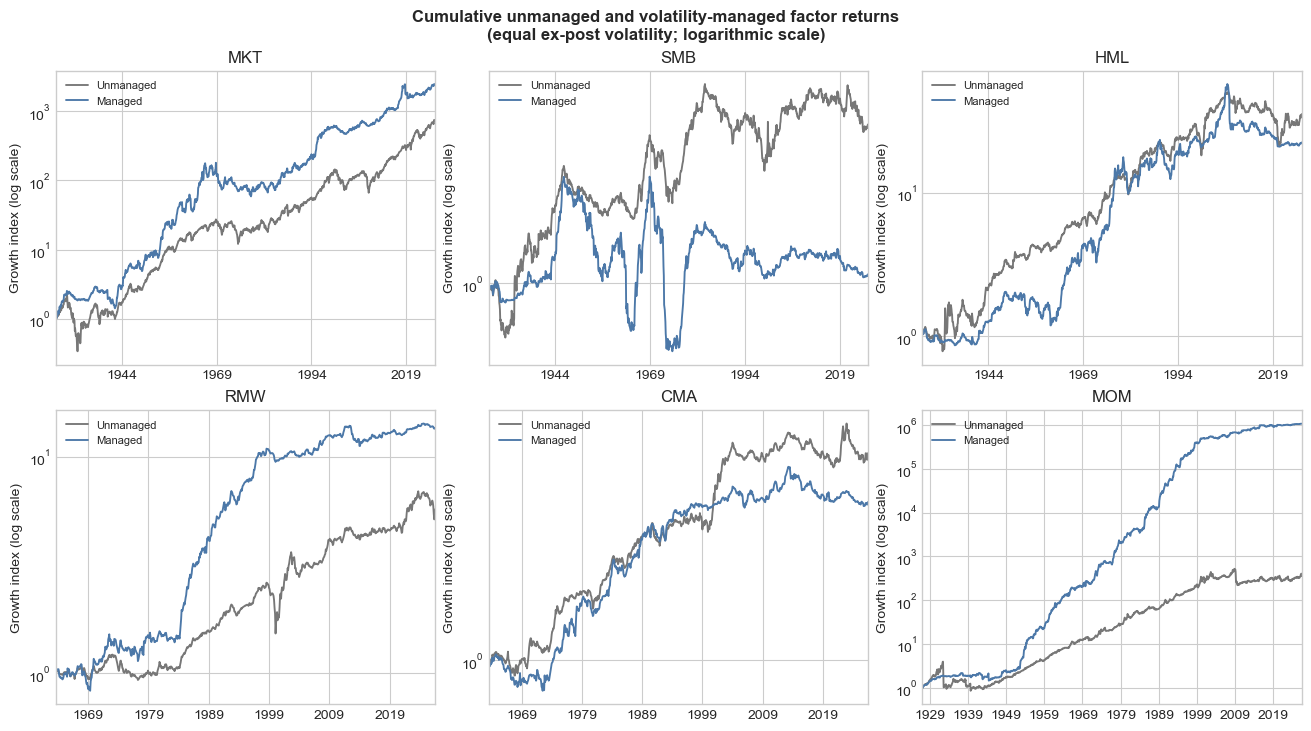

The cumulative panels compare each managed factor with its own unmanaged return at the same full-sample volatility. The evidence is visibly heterogeneous: RMW improves and momentum stands out, whereas the remaining managed paths do not consistently dominate. The logarithmic axes make proportional growth differences comparable across factors.

#### Risk-adjusted performance and own-factor spanning

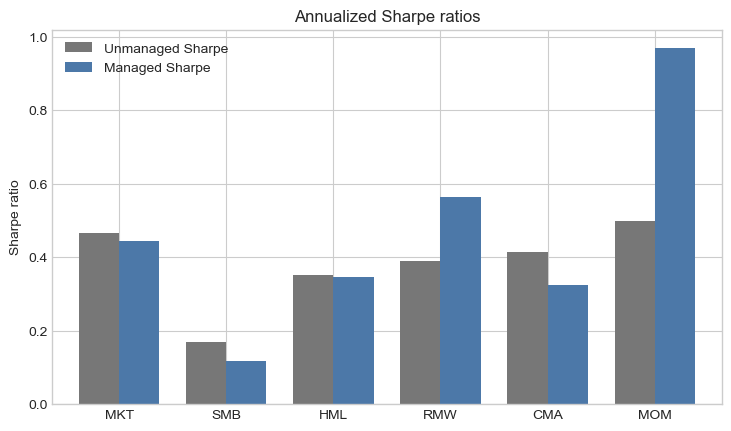

,Unmanaged SR,Managed SR,Alpha (% monthly),NW alpha t,Own-factor loading,NW loading t,Adjusted R²
Factor,,,,,,,
MKT,0.466,0.443,0.201,1.303,0.740,9.708,0.428
SMB,0.170,0.118,0.002,0.018,0.657,6.268,0.457
HML,0.350,0.346,0.138,1.148,0.759,6.703,0.378
RMW,0.389,0.562,0.204,2.924,0.505,4.184,0.314
CMA,0.415,0.325,0.028,0.650,0.596,7.433,0.436
MOM,0.498,0.970,0.950,5.463,0.567,5.612,0.266


In [3]:
original = pd.DataFrame({name: data[cols[0]] for name, cols in factor_columns.items()})
managed = pd.DataFrame({name: data[cols[2]] for name, cols in factor_columns.items()})
common = pd.concat(
    [original.add_suffix("_original"), managed.add_suffix("_managed")], axis=1
).dropna()

# Equalize volatility within each pair so the paths compare reward per unit of realized risk.
fig, axes = plt.subplots(2, 3, figsize=(13, 7.2), constrained_layout=True)
for ax, name in zip(axes.flat, factor_columns):
    pair = pd.concat([original[name], managed[name]], axis=1, keys=["Unmanaged", "Managed"]).dropna()
    pair["Managed"] *= pair["Unmanaged"].std() / pair["Managed"].std()
    wealth = (1 + pair).cumprod()
    wealth.plot(ax=ax, color=["#777777", "#4C78A8"], linewidth=1.35)
    ax.set_yscale("log")
    ax.set(title=name, xlabel="", ylabel="Growth index (log scale)")
    ax.legend(frameon=False, fontsize=8)
fig.suptitle("Cumulative unmanaged and volatility-managed factor returns\n(equal ex-post volatility; logarithmic scale)", weight="bold")
plt.show()

display(Markdown(
    "The cumulative panels compare each managed factor with its own unmanaged return at the same "
    "full-sample volatility. The evidence is visibly heterogeneous: RMW improves and momentum stands "
    "out, whereas the remaining managed paths do not consistently dominate. The logarithmic axes "
    "make proportional growth differences comparable across factors."
))

spanning_rows = []
for name in factor_columns:
    result = spanning_regression(
        common[f"{name}_managed"], common[[f"{name}_original"]], cov_type="HAC", hac_lags=12
    )
    spanning_rows.append({
        "Factor": name,
        "Unmanaged Sharpe": sharpe_ratio(common[f"{name}_original"]),
        "Managed Sharpe": sharpe_ratio(common[f"{name}_managed"]),
        "Alpha": 100 * result.params["const"],
        "Alpha SE": 100 * result.bse["const"],
        "Alpha t": result.tvalues["const"],
        "Own-factor loading": result.params.iloc[1],
        "Loading t": result.tvalues.iloc[1],
        "Adjusted R²": result.rsquared_adj,
    })
spanning_table = pd.DataFrame(spanning_rows).set_index("Factor")

display(Markdown("#### Risk-adjusted performance and own-factor spanning"))

fig, ax = plt.subplots(figsize=(7.2, 4.2), constrained_layout=True)
spanning_table[["Unmanaged Sharpe", "Managed Sharpe"]].plot.bar(
    ax=ax, color=["#777777", "#4C78A8"], width=0.75
)
ax.axhline(0, color="black", linewidth=0.7)
ax.set(title="Annualized Sharpe ratios", xlabel="", ylabel="Sharpe ratio")
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False)
plt.show()

spanning_display = spanning_table[[
    "Unmanaged Sharpe", "Managed Sharpe", "Alpha", "Alpha t",
    "Own-factor loading", "Loading t", "Adjusted R²",
]].copy()
spanning_display.columns = [
    "Unmanaged SR", "Managed SR", "Alpha (% monthly)", "NW alpha t",
    "Own-factor loading", "NW loading t", "Adjusted R²",
]
display(spanning_display)

The six return panels immediately show that volatility management is not uniformly successful. At a common volatility, the managed paths for MKT, SMB, HML, and CMA do not clearly dominate their unmanaged counterparts. RMW improves, while momentum is visually and statistically the clear outlier. The table confirms that only RMW and momentum have significantly positive own-factor alphas at the 5% level, and momentum's Sharpe ratio rises by far the most.

The own-factor loadings are positive and statistically significant for all six strategies. This is economically sensible: volatility management changes the amount invested in the original factor rather than replacing it with a different return source. The loadings are below one because the timing rule frequently scales exposure down, while adjusted $R^2$ shows that a constant exposure captures only part of the managed strategy's variation. The scaling rule is therefore a conditional exposure choice, not a mechanical guarantee of improvement.

### 2.3 Asset Pricing Tests: CAPM, FF3, FF5, and FF5 + Momentum

A managed return can outperform its unmanaged counterpart and still be explained by familiar systematic exposures. We therefore regress each managed factor on the CAPM, Fama–French three-factor, Fama–French five-factor, and FF5 augmented with ordinary momentum. The final specification is particularly demanding for volatility-managed momentum because it asks whether timing adds return after controlling directly for the unmanaged factor itself. For model factors $F_t$,

$$
f_t^{VM}=\alpha+\boldsymbol{\beta}'F_t+\varepsilon_t,
\qquad H_0:\alpha=0.
$$

The intercept measures average managed return not spanned by the selected model over this sample. The loadings show which unmanaged factors account for the managed return's time-series variation. Neither a significant alpha nor a significant loading, by itself, establishes mispricing or a structural source of risk compensation.

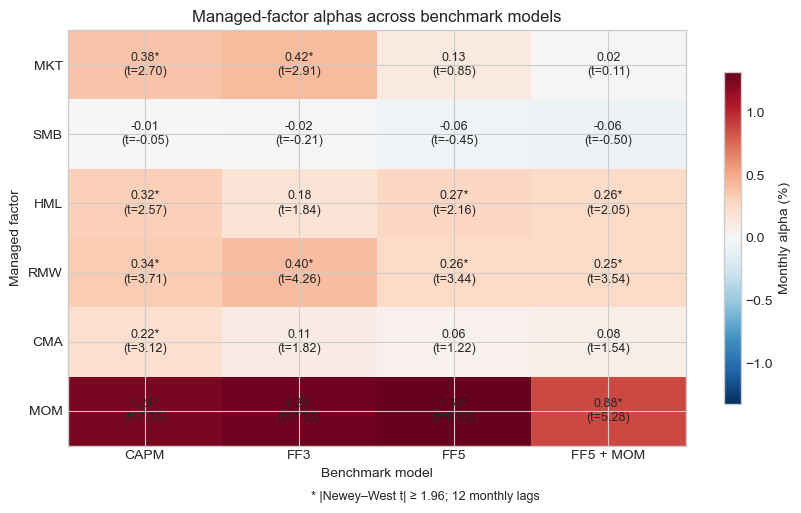

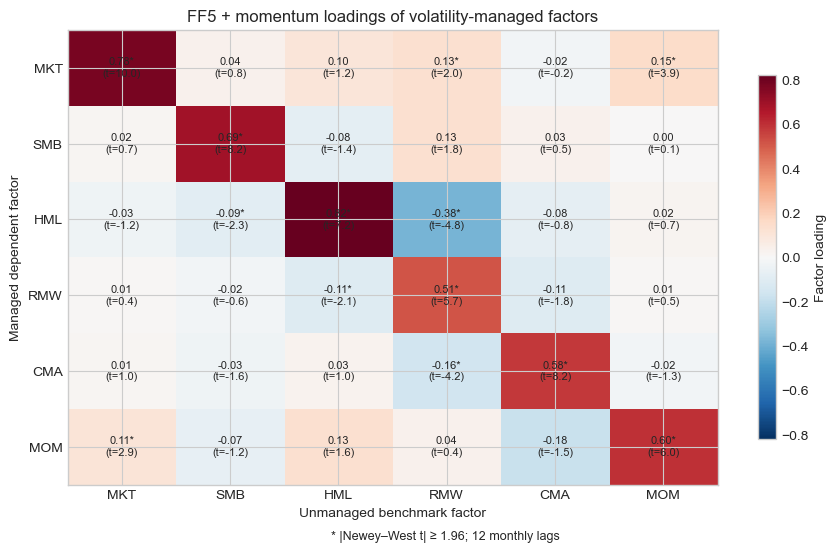

In [4]:
models = {
    "CAPM": ["mkt_rf"],
    "FF3": ["mkt_rf", "smb", "hml"],
    "FF5": ["ff5_mkt_rf", "ff5_smb", "ff5_hml", "rmw", "cma"],
    "FF5 + MOM": ["ff5_mkt_rf", "ff5_smb", "ff5_hml", "rmw", "cma", "mom"],
}

model_rows = []
model_fits = {}
for model_name, regressors in models.items():
    for factor_name, (_, _, managed_col, _) in factor_columns.items():
        sample = data[[managed_col, *regressors]].dropna()
        result = spanning_regression(
            sample[managed_col], sample[regressors], cov_type="HAC", hac_lags=12
        )
        model_fits[(factor_name, model_name)] = result
        model_rows.append({
            "Model": model_name,
            "Managed factor": factor_name,
            "Alpha (% monthly)": 100 * result.params["const"],
            "HAC t(alpha)": result.tvalues["const"],
            "Adjusted R²": result.rsquared_adj,
        })

model_table = pd.DataFrame(model_rows)
alpha_grid = model_table.pivot(index="Managed factor", columns="Model", values="Alpha (% monthly)")
t_grid = model_table.pivot(index="Managed factor", columns="Model", values="HAC t(alpha)")
alpha_grid = alpha_grid.loc[list(factor_columns), list(models)]
t_grid = t_grid.loc[list(factor_columns), list(models)]

fig, ax = plt.subplots(figsize=(8.6, 5.0))
limit = np.abs(alpha_grid.to_numpy()).max()
image = ax.imshow(alpha_grid, cmap="RdBu_r", aspect="auto", vmin=-limit, vmax=limit)
for row in range(alpha_grid.shape[0]):
    for col in range(alpha_grid.shape[1]):
        stars = "*" if abs(t_grid.iloc[row, col]) >= 1.96 else ""
        ax.text(col, row, f"{alpha_grid.iloc[row, col]:.2f}{stars}\n(t={t_grid.iloc[row, col]:.2f})",
                ha="center", va="center", fontsize=9)
ax.set(
    title="Managed-factor alphas across benchmark models",
    xlabel="Benchmark model", ylabel="Managed factor",
    xticks=range(len(alpha_grid.columns)), xticklabels=alpha_grid.columns,
    yticks=range(len(alpha_grid.index)), yticklabels=alpha_grid.index,
)
fig.colorbar(image, ax=ax, label="Monthly alpha (%)", shrink=0.8)
fig.text(0.5, -0.01, "* |Newey–West t| ≥ 1.96; 12 monthly lags", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

richest_model = "FF5 + MOM"
regressor_labels = {
    "ff5_mkt_rf": "MKT", "ff5_smb": "SMB", "ff5_hml": "HML",
    "rmw": "RMW", "cma": "CMA", "mom": "MOM",
}
loading_grid = pd.DataFrame(index=factor_columns, columns=regressor_labels.values(), dtype=float)
loading_t_grid = loading_grid.copy()
for factor_name in factor_columns:
    fit = model_fits[(factor_name, richest_model)]
    for regressor, label in regressor_labels.items():
        loading_grid.loc[factor_name, label] = fit.params[regressor]
        loading_t_grid.loc[factor_name, label] = fit.tvalues[regressor]

fig, ax = plt.subplots(figsize=(9, 5.4))
loading_limit = np.abs(loading_grid.to_numpy()).max()
image = ax.imshow(loading_grid, cmap="RdBu_r", aspect="auto",
                  vmin=-loading_limit, vmax=loading_limit)
for row in range(loading_grid.shape[0]):
    for col in range(loading_grid.shape[1]):
        stars = "*" if abs(loading_t_grid.iloc[row, col]) >= 1.96 else ""
        ax.text(col, row, f"{loading_grid.iloc[row, col]:.2f}{stars}\n(t={loading_t_grid.iloc[row, col]:.1f})",
                ha="center", va="center", fontsize=8)
ax.set(
    title="FF5 + momentum loadings of volatility-managed factors",
    xlabel="Unmanaged benchmark factor", ylabel="Managed dependent factor",
    xticks=range(len(loading_grid.columns)), xticklabels=loading_grid.columns,
    yticks=range(len(loading_grid.index)), yticklabels=loading_grid.index,
)
fig.colorbar(image, ax=ax, label="Factor loading", shrink=0.8)
fig.text(0.5, -0.01, "* |Newey–West t| ≥ 1.96; 12 monthly lags", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

Volatility-managed momentum remains the strongest result under the CAPM, FF3, and FF5. Adding ordinary momentum is the more stringent test: its monthly alpha falls to about 0.88%, but remains highly significant with a Newey–West $t$-statistic of 5.28. At the same time, volatility-managed momentum has a MOM loading of about 0.60 ($t=6.00$). It is therefore clearly related to ordinary momentum, as a timed version should be, but a constant combination of FF5 and MOM still does not reproduce its average return.

The broader loading heatmap reinforces this interpretation. The large, significant diagonal loadings show that most managed factors retain substantial exposure to their underlying unmanaged factors; volatility management changes exposure through time rather than creating unrelated return sources. The off-diagonal estimates reveal overlap with other benchmarks, while the alpha heatmap shows whether those combined constant exposures span the managed return.

### 2.4 Downside-risk management

Sharpe ratios summarize average return per unit of total volatility, but momentum is particularly exposed to abrupt reversals. We therefore also report the empirical 5% loss quantile, expected shortfall conditional on being in that tail, maximum drawdown, skewness, and excess kurtosis. These are descriptive in-sample measures rather than guarantees about future losses.

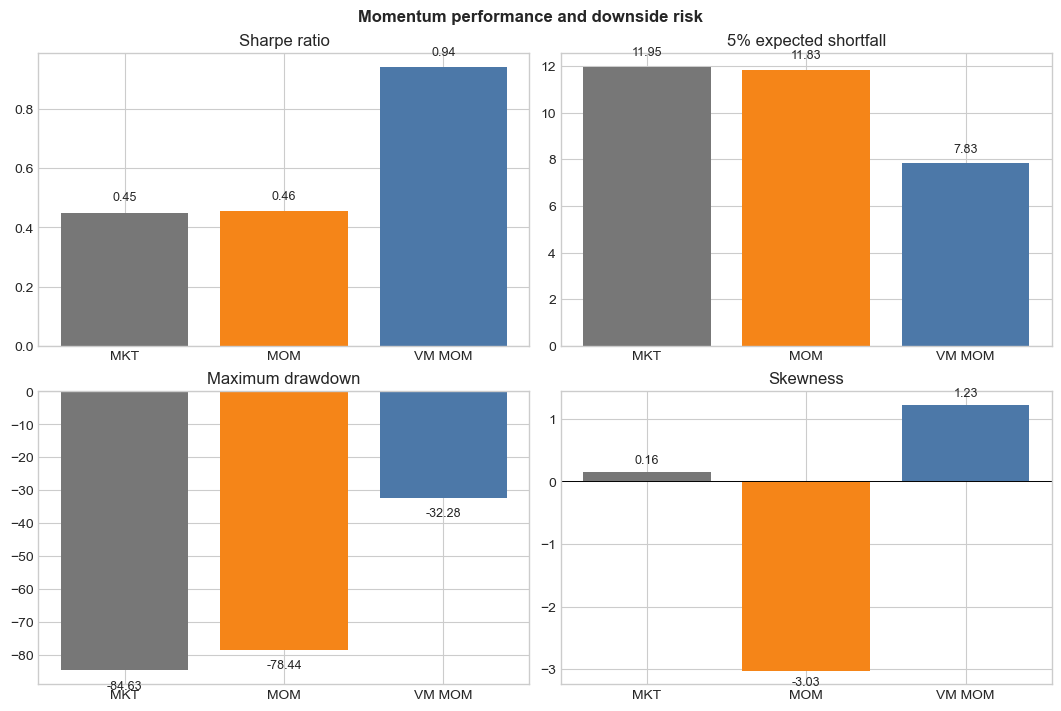

In [5]:
def downside_statistics(series):
    returns = series.dropna()
    wealth = (1 + returns).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    cutoff = returns.quantile(0.05)
    return {
        "Annualized Sharpe": sharpe_ratio(returns),
        "5% loss quantile (%)": -100 * cutoff,
        "Expected shortfall (%)": -100 * returns[returns <= cutoff].mean(),
        "Maximum drawdown (%)": 100 * drawdown.min(),
        "Skewness": returns.skew(),
        "Excess kurtosis": returns.kurt(),
    }

momentum_sample = data[["mkt_rf", "mom", "managed_mom"]].dropna()
risk_table = pd.DataFrame({
    "Market": downside_statistics(momentum_sample["mkt_rf"]),
    "Momentum": downside_statistics(momentum_sample["mom"]),
    "Volatility-managed momentum": downside_statistics(momentum_sample["managed_mom"]),
}).T

metrics = ["Annualized Sharpe", "Expected shortfall (%)", "Maximum drawdown (%)", "Skewness"]
titles = ["Sharpe ratio", "5% expected shortfall", "Maximum drawdown", "Skewness"]
colors = ["#777777", "#F58518", "#4C78A8"]
fig, axes = plt.subplots(2, 2, figsize=(10.5, 7), constrained_layout=True)
for ax, metric, title in zip(axes.flat, metrics, titles):
    values = risk_table[metric]
    ax.bar(range(len(values)), values, color=colors)
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set(title=title, xticks=range(len(values)), xticklabels=["MKT", "MOM", "VM MOM"])
    for position, value in enumerate(values):
        offset = 3 if metric == "Maximum drawdown (%)" else 0.03 * max(abs(values).max(), 1)
        ax.text(position, value + (offset if value >= 0 else -offset), f"{value:.2f}",
                ha="center", va="bottom" if value >= 0 else "top", fontsize=9)
fig.suptitle("Momentum performance and downside risk", weight="bold")
plt.show()

Ordinary momentum has a deep maximum drawdown and strongly negative skewness, consistent with its well-known crash exposure. Volatility-managed momentum has a markedly higher Sharpe ratio, a substantially smaller drawdown, less severe expected shortfall, and positive sample skewness. The companion analysis shows that the average gain comes mainly from scaling up the historically attractive low-volatility states, while reduced exposure after turbulent months improves relative performance in the worst states. The rule reacts to lagged volatility; it does not predict the onset of a crash or recession.

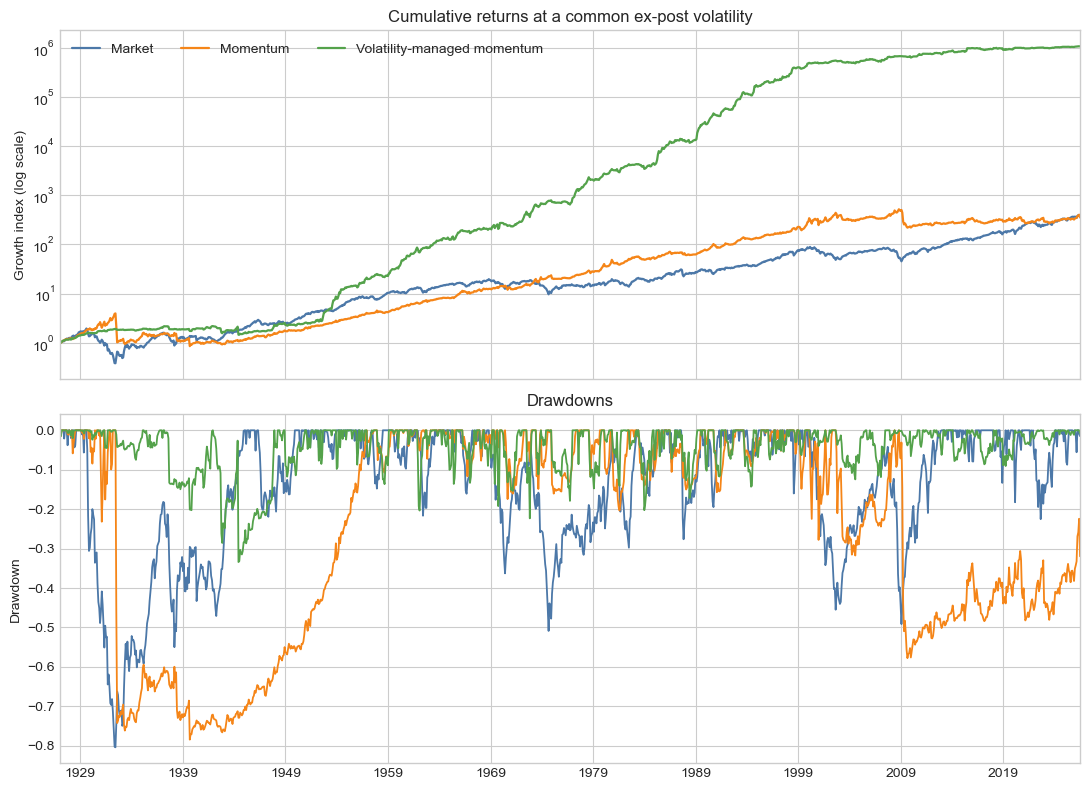

In [6]:
# Put the three series on momentum's full-sample volatility for a visual risk comparison.
target_volatility = momentum_sample["mom"].std()
scaled = momentum_sample.mul(target_volatility / momentum_sample.std())
scaled.columns = ["Market", "Momentum", "Volatility-managed momentum"]

wealth = (1 + scaled).cumprod()
drawdowns = wealth.div(wealth.cummax()).sub(1)

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
colors = ["#4C78A8", "#F58518", "#54A24B"]
wealth.plot(ax=axes[0], color=colors, linewidth=1.6)
axes[0].set_yscale("log")
axes[0].set_title("Cumulative returns at a common ex-post volatility")
axes[0].set_ylabel("Growth index (log scale)")
axes[0].legend(frameon=False, ncol=3)

drawdowns.plot(ax=axes[1], color=colors, linewidth=1.3)
axes[1].set_title("Drawdowns")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("")
axes[1].legend().remove()
plt.tight_layout()
plt.show()

At the same ex-post volatility, managed momentum compounds more strongly and avoids much of ordinary momentum's prolonged crash drawdowns. The logarithmic scale keeps the market and unmanaged momentum paths visible despite the large difference in terminal values. The cumulative series is a normalized growth index for comparing return paths; because momentum is a self-financing factor and the strategy may use leverage, it should not be read as the wealth of an unconstrained, transaction-cost-free investor.

**Limitations.** The central result is specific rather than universal. Lagged inverse-variance scaling adds strong time-series alpha and improves downside outcomes for momentum, with smaller or less robust gains for most Fama–French factors. The evidence is in-sample and gross of implementation frictions; the weights are uncapped, and the volatility-matching constant uses full-sample information. A deployable strategy would require real-time normalization, leverage limits, financing and trading costs, and out-of-sample evaluation. The companion project provides the fuller replication and robustness analysis.